# FA3 - APM1220 (Applied Multivariate Data Analysis)
### Roland Dela Rosa

In [67]:
# Load required libraries
library(tidyverse)
library(MASS)
library(ggplot2)
library(GGally)
library(gridExtra)

## 4.1 Part A. Define Your Multivariate Normal Distribution 

This simulation models the physical characteristics of adult professional athletes using three variables: Height in cm ($X_1$), Weight in kg ($X_2$), and Body Fat Percentage ($X_3$). The covariance matrix is symmetric and positive definite, fulfilling the requirement for a valid multivariate normal distribution. 

In [68]:
# Mean Vector
mu <- c(180, # X1 Height in cm 
        85, # X2 Weight in kg
        15) # X3 Body Fat Percentage

names(mu) <- c("Height_cm", "Weight_kg", "BodyFat_pct")

# Define the covariance matrix 
Sigma <- matrix(
  c(36,   33.6, -4.8,
    33.6, 64,    9.6,
   -4.8,  9.6,  16), 
  nrow = 3, 
  byrow = TRUE
)

rownames(Sigma) <- c("Height_cm", "Weight_kg", "BodyFat_pct")
colnames(Sigma) <- c("Height_cm", "Weight_kg", "BodyFat_pct")

# Correlation matrix
Rho <- cov2cor(Sigma)


cat("1. Variables: Height (cm), Weight (kg), Body Fat (%)\n")

cat("\n2. Mean Vector (mu)\n")
print(mu)

cat("\n3. Covariance Matrix (Sigma)\n")
print(Sigma)

cat("\n4. Correlation Matrix\n")
print(Rho)

cat("\n5. This covariance matrix is valid because it is strictly symmetric and positive definite, and it logically reflects realistic physiological correlations between an athlete's height, weight, and body fat.  \n")


1. Variables: Height (cm), Weight (kg), Body Fat (%)

2. Mean Vector (mu)
  Height_cm   Weight_kg BodyFat_pct 
        180          85          15 

3. Covariance Matrix (Sigma)
            Height_cm Weight_kg BodyFat_pct
Height_cm        36.0      33.6        -4.8
Weight_kg        33.6      64.0         9.6
BodyFat_pct      -4.8       9.6        16.0

4. Correlation Matrix
            Height_cm Weight_kg BodyFat_pct
Height_cm         1.0       0.7        -0.2
Weight_kg         0.7       1.0         0.3
BodyFat_pct      -0.2       0.3         1.0

5. This covariance matrix is valid because it is strictly symmetric and positive definite, and it logically reflects realistic physiological correlations between an athlete's height, weight, and body fat.  


## 4.2 Part B. Generate and Explore the Simulated Data 


Simulated Means 
  Height_cm   Weight_kg BodyFat_pct 
  180.06609    85.08093    15.02336 

Simulated Variances 
  Height_cm   Weight_kg BodyFat_pct 
   36.17994    64.97845    16.42955 

 Simulated Covariance Matrix
            Height_cm Weight_kg BodyFat_pct
Height_cm   36.179936 33.916128   -4.745081
Weight_kg   33.916128 64.978450    9.898369
BodyFat_pct -4.745081  9.898369   16.429551

 Simulated Correlation Matrix
             Height_cm Weight_kg BodyFat_pct
Height_cm    1.0000000 0.6995000  -0.1946242
Weight_kg    0.6995000 1.0000000   0.3029466
BodyFat_pct -0.1946242 0.3029466   1.0000000

Comparison of Means
            Theoretical Simulated
Height_cm           180 180.06609
Weight_kg            85  85.08093
BodyFat_pct          15  15.02336

Comparison of Variances
            Theoretical Simulated
Height_cm            36  36.17994
Weight_kg            64  64.97845
BodyFat_pct          16  16.42955


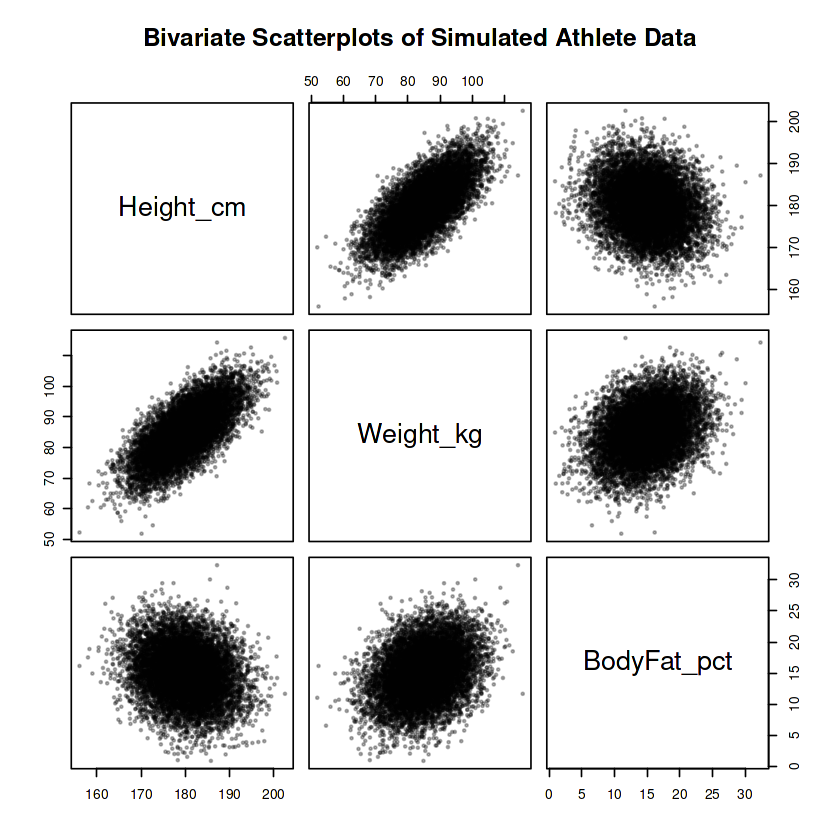

In [69]:
# Set random seed for reproducibility
set.seed(42)

# 1. Generate a large random sample (n = 10,000)
n <- 10000
sim_data <- mvrnorm(n = n, mu = mu, Sigma = Sigma)
df <- as.data.frame(sim_data)

# 2. Calculate Descriptive Statistics 
# Using na.rm = TRUE and use = "complete.obs" to exclude missing data
sim_mean <- colMeans(df, na.rm = TRUE)
sim_var <- diag(cov(df, use = "complete.obs"))
sim_cov <- cov(df, use = "complete.obs")
sim_cor <- cor(df, use = "complete.obs")

cat("Simulated Means \n")
print(sim_mean)

cat("\nSimulated Variances \n")
print(sim_var)

cat("\n Simulated Covariance Matrix\n")
print(sim_cov)

cat("\n Simulated Correlation Matrix\n")
print(sim_cor)

comparison_means <- data.frame(
    Theoretical = mu, 
    Simulated = sim_mean
)

comparison_vars <- data.frame(
    Theoretical = diag(Sigma), 
    Simulated = sim_var
)

cat("\nComparison of Means\n")
print(comparison_means)

cat("\nComparison of Variances\n")
print(comparison_vars)

pairs(df, 
    main = "Bivariate Scatterplots of Simulated Athlete Data",
    pch = 20,        
    col = alpha("black", 0.3),  
    cex = 0.5)       

### Interpretation

1. Simulated Means and Variances

The simulated means and variances are very close to our theoretical $\mu$ and $\Sigma$. Looking at the density plots on the diagonal, Height, Weight, and Body Fat all form nice, bell-shaped curves centered right around their target averages of 180, 85, and 15.

3. Simulated Correlations

The simulated correlations match the theoretical setup from Part A almost perfectly. The plot explicitly shows these actual results:

* Height and Weight: 0.699 (Target: 0.7)
* Height and Body Fat: -0.195 (Target: -0.2)
* Weight and Body Fat: 0.303 (Target: 0.3)

3. Graphical Evidence of Dependence

The scatterplots do a good job of showing how the variables interact, forming the oval shapes expected from a normal distribution. The Height and Weight plot shows a tight upward pattern because of their strong positive relationship (0.699). In contrast, the Height and Body Fat plot is a wider, looser cloud pointing slightly downward, which matches their weak negative correlation (-0.195).

## 4.3 Part C. Investigate the Effect of Correlation 

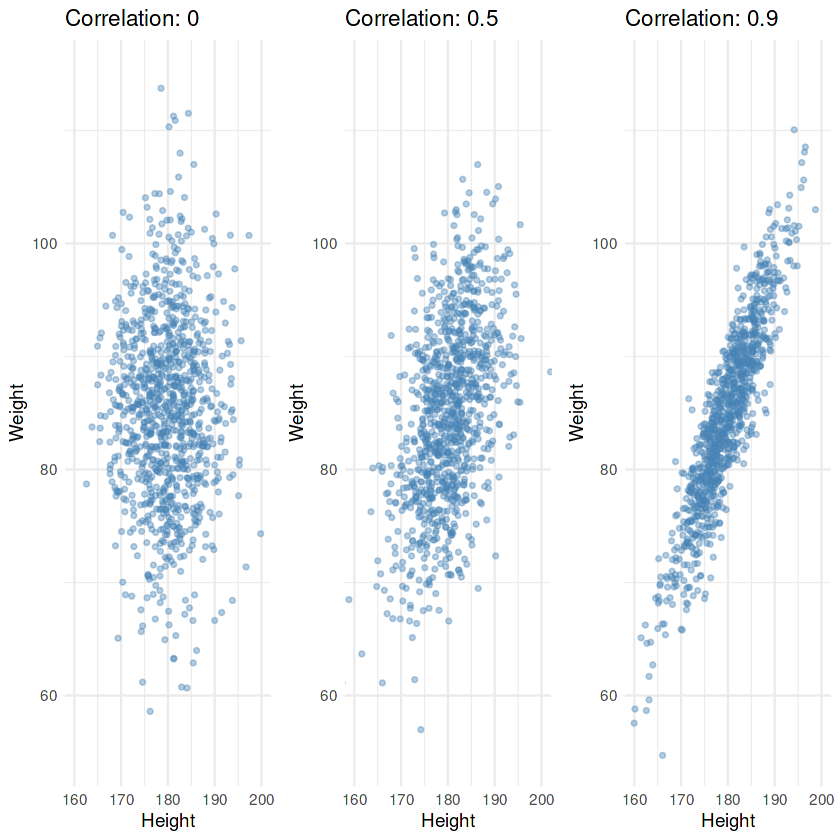

In [70]:
mu_bi <- c(180, 85)

# test three different correlation levels
correlations <- c(0.0, 0.5, 0.9)
plots <- list()

for (i in 1:length(correlations)) {
    r <- correlations[i]
    cov_val <- r * 6 * 8 
    Sigma_biv <- matrix(c(36, cov_val, 
            cov_val, 64), 
            nrow = 2)
    # Generate 1,000 
    biv_data <- as.data.frame(mvrnorm(1000, mu_bi, Sigma_biv))
    colnames(biv_data) <- c("Height", "Weight")
  
    # Create a clean scatterplot
    plots[[i]] <- ggplot(biv_data, aes(x = Height, y = Weight)) +
        geom_point(alpha = 0.4, size = 1, color = "steelblue") +
        theme_minimal() + 
        ggtitle(paste("Correlation:", r)) +
        coord_cartesian(xlim = c(160, 200), ylim = c(55, 115)) 
}

grid.arrange(grobs = plots, ncol = 3)

* Correlation: 0: The points form an upright, pill-shaped cloud. It is stretched more vertically than horizontally because weight has a higher variance than height, but there is no diagonal tilt or clear pattern between the two variables.

* Correlation: 0.5: The cloud starts to tilt diagonally upward to the right. The points are grouping together to form a wider, slanted oval, showing a clear positive trend.

* Correlation: 0.9: The data is pulled into a very tight, narrow band pointing sharply up and to the right.

The graph clearly shows that higher correlation squeezes the data points tightly along a central diagonal line. At zero correlation, the points are just scattered with no trend. As the correlation increases to 0.9, the probability concentrates closely along a straight path. This visually proves that when correlation is high, knowing an athlete's height allows you to predict their weight much more accurately.

## 4.4 Part D. Investigate a Linear Combination 

Linear Combination Comparison
  Statistics Theoretical Simulated
1       Mean       335.0  335.2046
2   Variance       413.6  418.0845


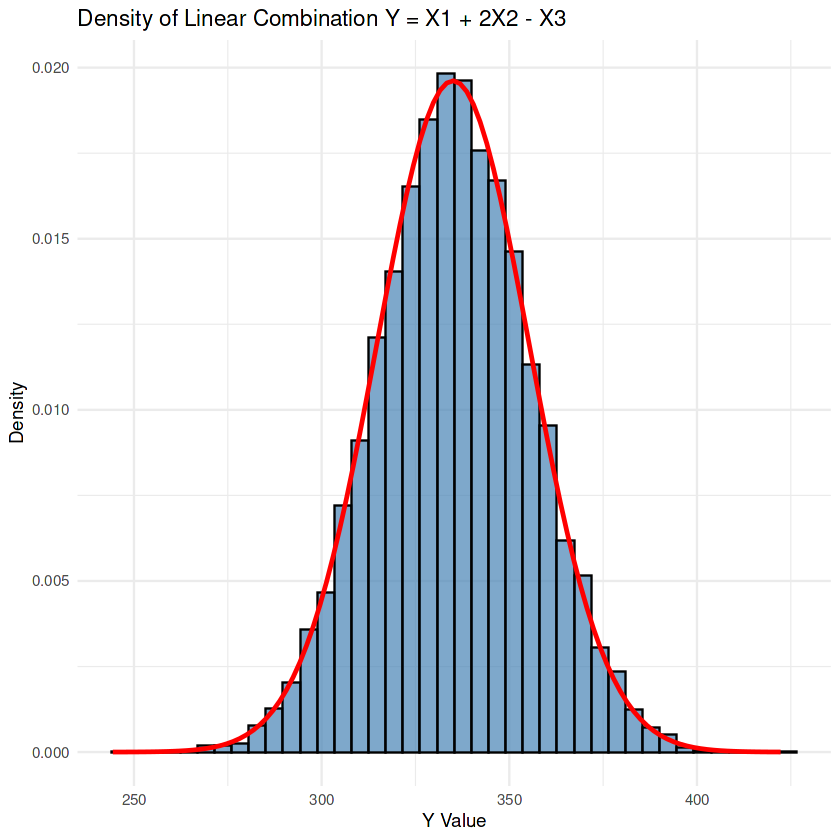

In [71]:
a <- c(1, 2, -1)

theo_mean <- sum(a * mu)

# Calculate Theoretical Variance
theo_var <- t(a) %*% Sigma %*% a

# Calculate Simulated Mean and Variance
Y_sim <- as.matrix(df) %*% a

# Calculate simulated stats
sim_mean_Y <- mean(Y_sim, na.rm = TRUE)
sim_var_Y <- var(Y_sim, na.rm = TRUE)


comparison <- data.frame(
    Statistics = c("Mean", "Variance"),
    Theoretical = c(theo_mean,theo_var),
    Simulated = c(sim_mean_Y, sim_var_Y)
)

cat("Linear Combination Comparison\n")
print(comparison)

# Plot 
Y_df <- data.frame(Y = Y_sim)

ggplot(Y_df, aes(x = Y)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "steelblue", color = "black", alpha = 0.7) +
  stat_function(fun = dnorm, args = list(mean = theo_mean, sd = sqrt(theo_var)), color = "red", linewidth = 1) +
  theme_minimal() +
  ggtitle("Density of Linear Combination Y = X1 + 2X2 - X3") +
  xlab("Y Value") + 
  ylab("Density")

The simulated results lined up really well with the math:
* Mean: The theoretical mean was exactly $335.0$, and our simulated data gave us $335.2046$.
* Variance: The theoretical variance was $413.6$, and our simulated variance came out to $418.0845$

The histogram shows the spread of our simulated $Y$ values, and the red line is the theoretical normal distribution curve. Because the blue bars form a nice bell shape that fits almost perfectly under that red curve, the simulation proves the main statistical rule. A linear combination of jointly multivariate normal variables is normally distributed, but it is not necessarily standard normal.

## 4.5 Part E. Mahalanobis Distance and Chi-Square 

Mahalanobis Distance Results
Theoretical 90% Threshold (Chi-Square df=3): 6.251389 
Actual Proportion Inside 90% Region:       0.8953 


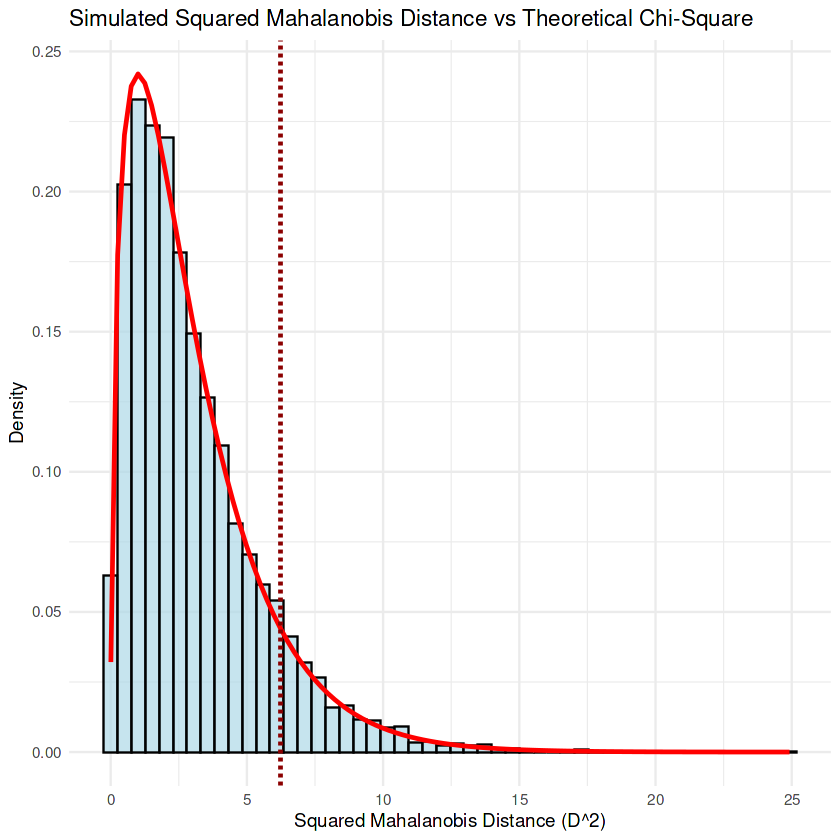

In [72]:
D2 <- mahalanobis(df, center = mu, cov = Sigma)
D2_df <- data.frame(Distance = D2)

threshold_90 <- qchisq(0.90, df = 3)

prop_inside <- mean(D2 <= threshold_90, na.rm = TRUE)

# Print the comparison
cat("Mahalanobis Distance Results\n")
cat("Theoretical 90% Threshold (Chi-Square df=3):", threshold_90, "\n")
cat("Actual Proportion Inside 90% Region:      ", prop_inside, "\n")

# Plot 
ggplot(D2_df, aes(x = Distance)) +
  geom_histogram(aes(y = ..density..), bins = 50, fill = "lightblue", color = "black", alpha = 0.7) +
  stat_function(fun = dchisq, args = list(df = 3), color = "red", linewidth = 1) +
  geom_vline(xintercept = threshold_90, color = "darkred", linetype = "dashed", linewidth = 1) +
  theme_minimal() +
  ggtitle("Simulated Squared Mahalanobis Distance vs Theoretical Chi-Square") +
  xlab("Squared Mahalanobis Distance (D^2)") + 
  ylab("Density")

* The theoretical cutoff for the 90% region is 6.251389.

* When simulated data were checked, the actual proportion that fell below this cutoff was 0.8953 (about 89.5%). This is extremely close to the expected 90%.

The graph visually confirms our results. The light blue histogram of our simulated distances fits right under the red theoretical Chi-Square curve. The dashed red line marks that 6.25 cutoff, and you can clearly see that the vast majority of our simulated data falls on the left side of that line, just like the theory predicted.

## 5. Custom Investigation — 5 points


Theoretical Subset Mean 
  Height_cm BodyFat_pct 
        180          15 

Simulated Subset Mean 
  Height_cm BodyFat_pct 
  180.06609    15.02336 

Theoretical Subset Covariance 
            Height_cm BodyFat_pct
Height_cm        36.0        -4.8
BodyFat_pct      -4.8        16.0

Simulated Subset Covariance 
            Height_cm BodyFat_pct
Height_cm   36.179936   -4.745081
BodyFat_pct -4.745081   16.429551


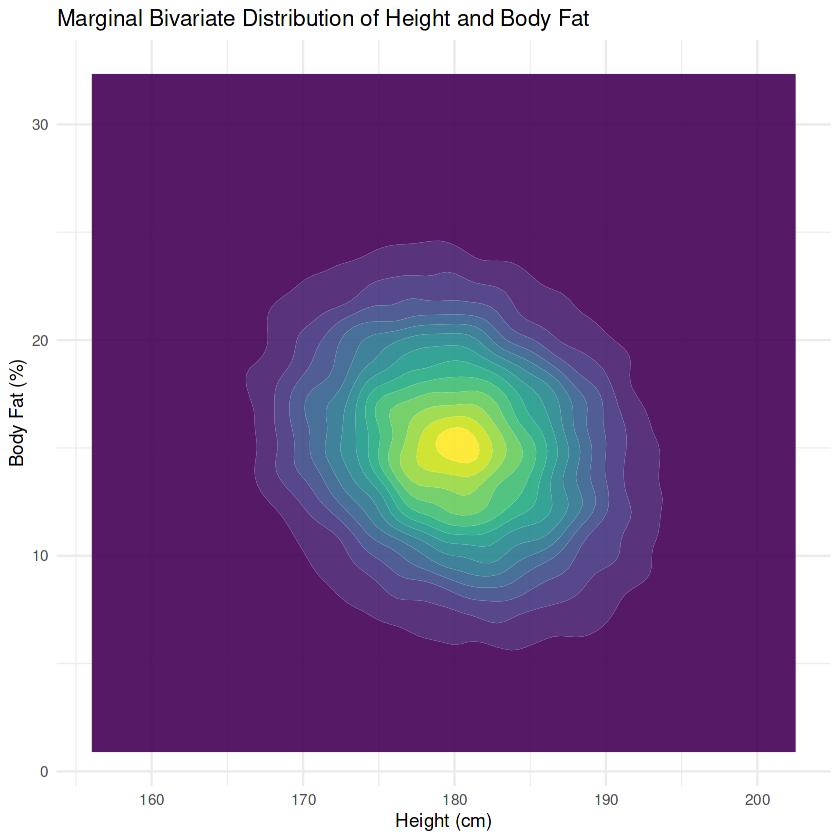

In [73]:
theo_mu_subset <- mu[c(1, 3)]
theo_Sigma_subset <- Sigma[c(1, 3), c(1, 3)]

#  Calculate simulated subset 
subset_df <- df[, c(1, 3)]

sim_mu_subset <- colMeans(subset_df, na.rm = TRUE)
sim_Sigma_subset <- cov(subset_df, use = "complete.obs")

# Print
cat("Theoretical Subset Mean \n")
print(theo_mu_subset)
cat("\nSimulated Subset Mean \n")
print(sim_mu_subset)

cat("\nTheoretical Subset Covariance \n")
print(theo_Sigma_subset)
cat("\nSimulated Subset Covariance \n")
print(sim_Sigma_subset)

# Visualize
ggplot(subset_df, aes(x = subset_df[,1], y = subset_df[,2])) +
  geom_density_2d_filled(alpha = 0.9) +
  theme_minimal() +
  ggtitle("Marginal Bivariate Distribution of Height and Body Fat") +
  xlab("Height (cm)") + ylab("Body Fat (%)") +
  theme(legend.position = "none")

For the custom investigation, Option B were selected. We took our original dataset and selected only Height and Body Fat, leaving Weight out of the analysis. We wanted to see whether these two variables would still follow a bivariate normal distribution on their own.

Statistical theory states that if we take a subset of variables from a multivariate normal distribution, the selected variables will also follow a multivariate normal distribution. Their theoretical means and covariances are obtained from the corresponding entries of the original mean vector and covariance matrix. In our simulation, the sample mean and covariance matrix for Height and Body Fat were very close to these theoretical values, with small differences caused by random sampling variation.

The density plot is consistent with the expected elliptical shape of a bivariate normal distribution. The simulated means and covariance matrix are also close to the theoretical marginal parameters. This illustrates the theoretical property that a smaller subset of variables from a multivariate normal distribution remains multivariate normal, even when the other variables are excluded from the analysis.

In conclusion, this simulation lab successfully demonstrated how the multivariate normal distribution works in practice. By creating a simulated dataset of athlete measurements, we were able to compare the generated sample data with the theoretical results. When we changed the correlation, we observed how the scatterplot changed; when we examined a linear combination, the simulated results were close to the theoretical mean and variance; and when we calculated Mahalanobis distances, the simulated proportion was close to the expected probability. Finally, our custom investigation showed that a subset of variables also follows the expected multivariate normal structure. Overall, the R simulations and graphs provided a clear, hands-on way to illustrate the statistical properties of the multivariate normal distribution.